In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.impute import SimpleImputer
import numpy as np
import seaborn as sns


Should probably start by cleaning the data 

In [2]:
df = pd.read_csv("../data/drug_discovery_virtual_screening.csv")

In [3]:
df.dtypes

compound_id             object
protein_id              object
molecular_weight       float64
logp                   float64
h_bond_donors            int64
h_bond_acceptors         int64
rotatable_bonds          int64
polar_surface_area     float64
compound_clogp         float64
protein_length           int64
protein_pi             float64
hydrophobicity         float64
binding_site_size      float64
mw_ratio               float64
logp_pi_interaction    float64
binding_affinity       float64
active                   int64
dtype: object

In [3]:
df = df.drop(['compound_id', 'protein_id'], axis=1)

In [4]:
si = SimpleImputer(missing_values=np.nan, strategy='mean')
si = si.fit(df)
df = pd.DataFrame(si.transform(df), columns=df.columns)

### Heatmap of Correlations

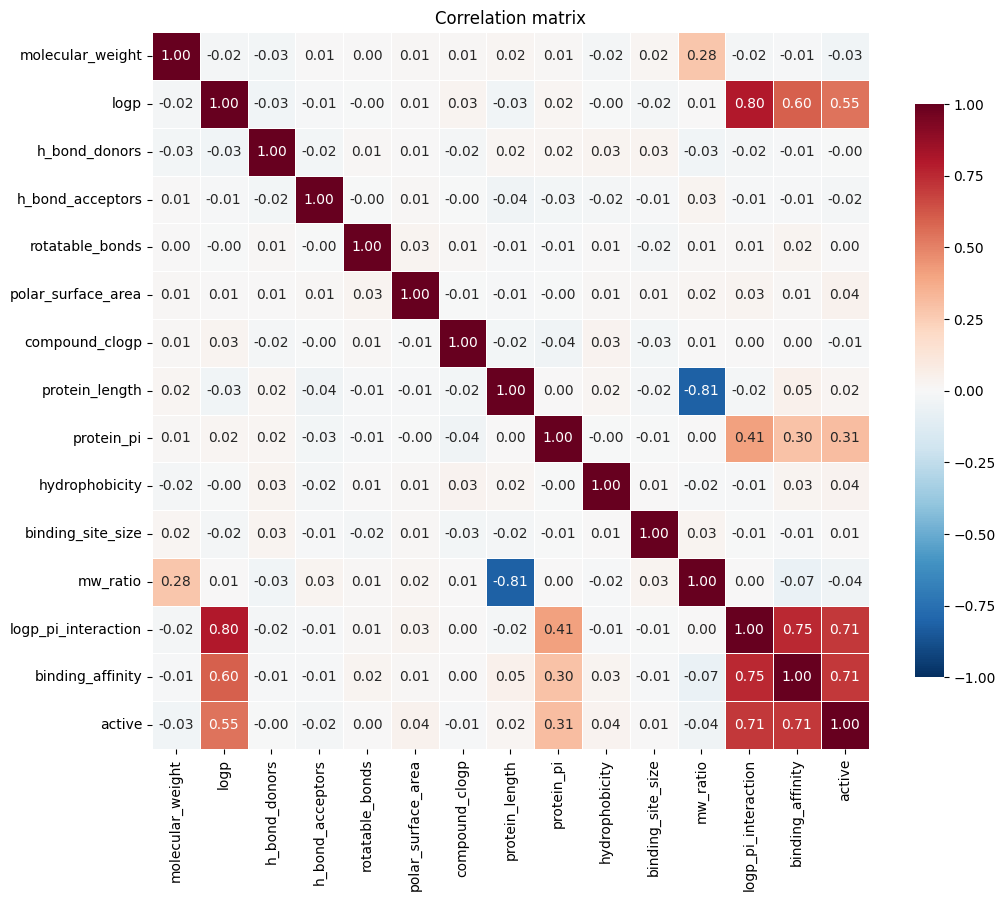

In [21]:
plt.figure(figsize=(11, 9))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

In [12]:
df.corr()["active"].drop("active").sort_values(key=abs, ascending=False)

binding_affinity       0.710852
logp_pi_interaction    0.706134
logp                   0.546438
protein_pi             0.307753
polar_surface_area     0.040911
mw_ratio              -0.039124
hydrophobicity         0.035528
molecular_weight      -0.034495
h_bond_acceptors      -0.021419
protein_length         0.017372
compound_clogp        -0.011237
binding_site_size      0.005731
rotatable_bonds        0.003230
h_bond_donors         -0.001845
Name: active, dtype: float64

Histograms my beloved 

(Checking the distributions for anything weird)

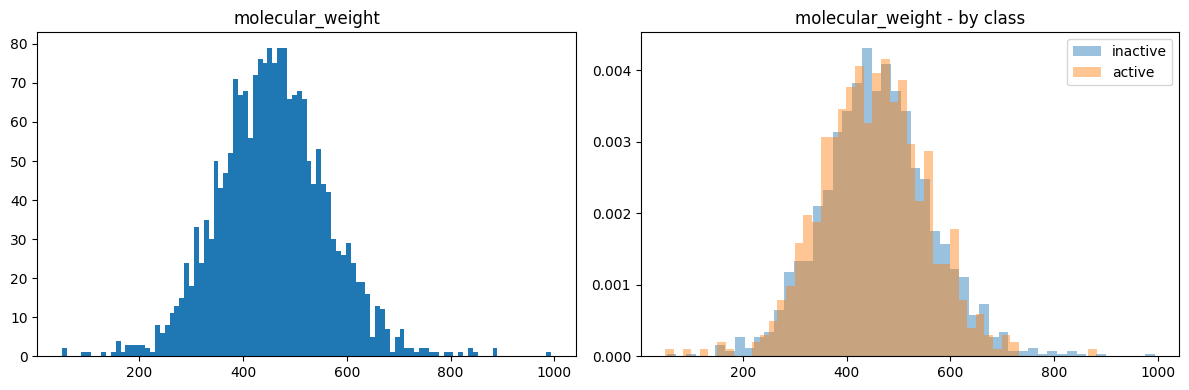

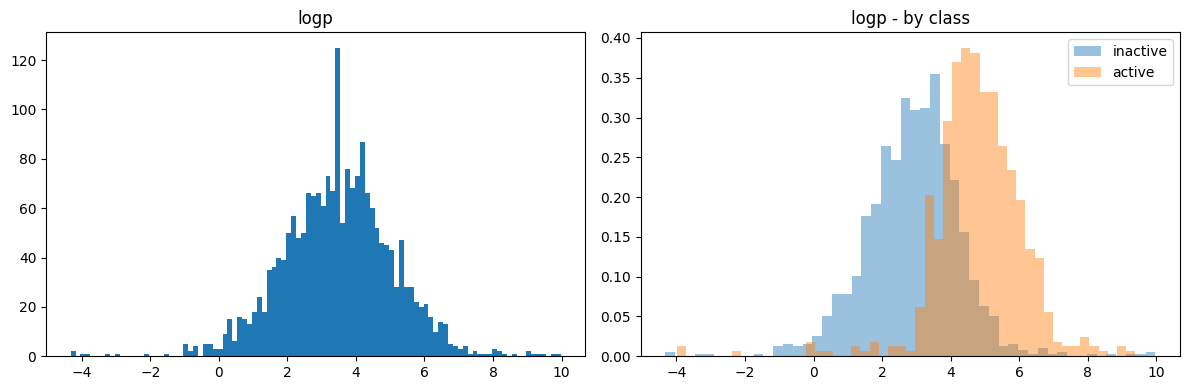

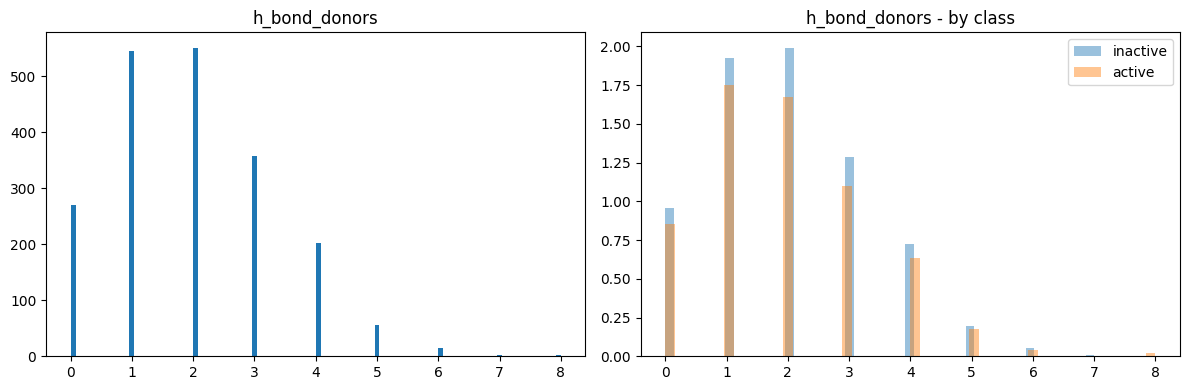

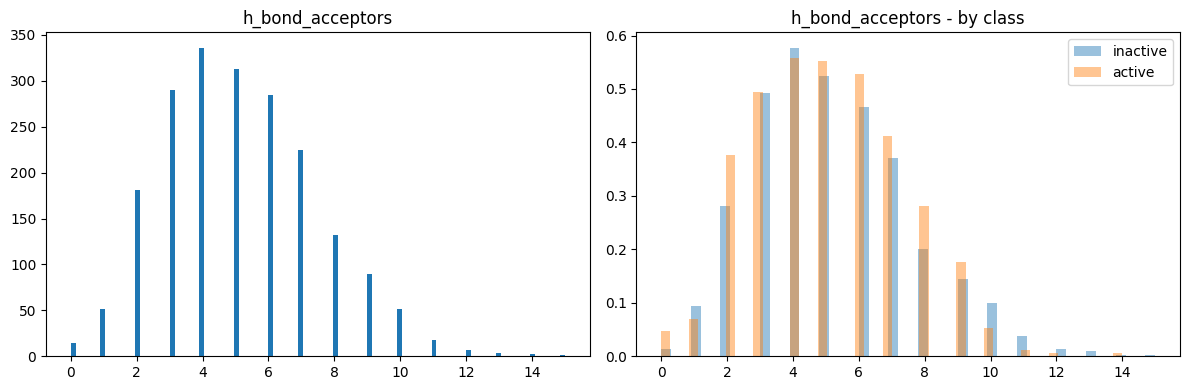

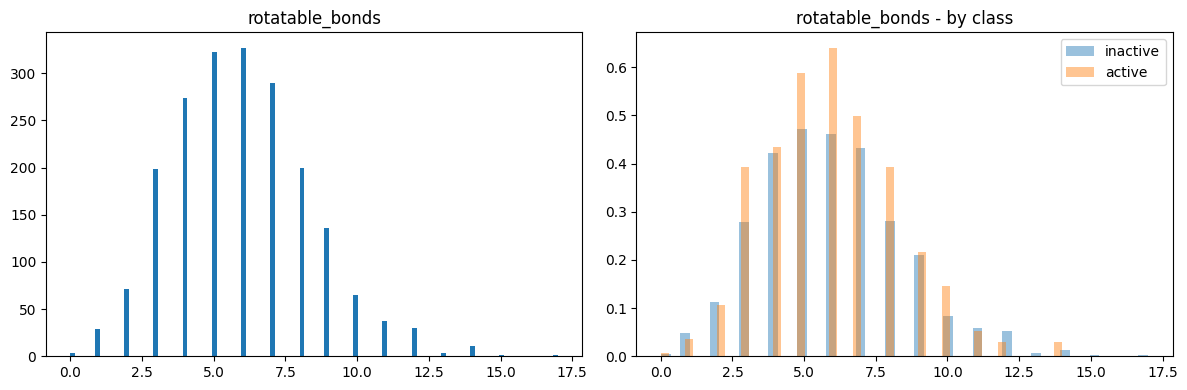

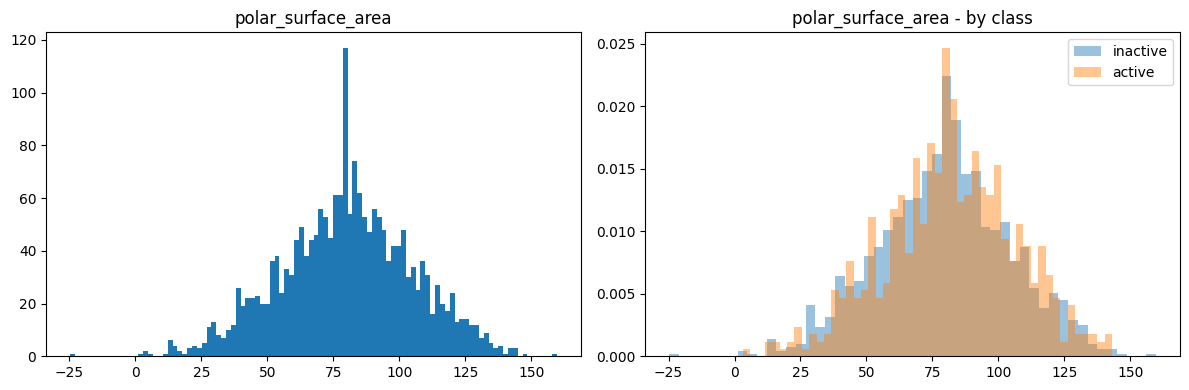

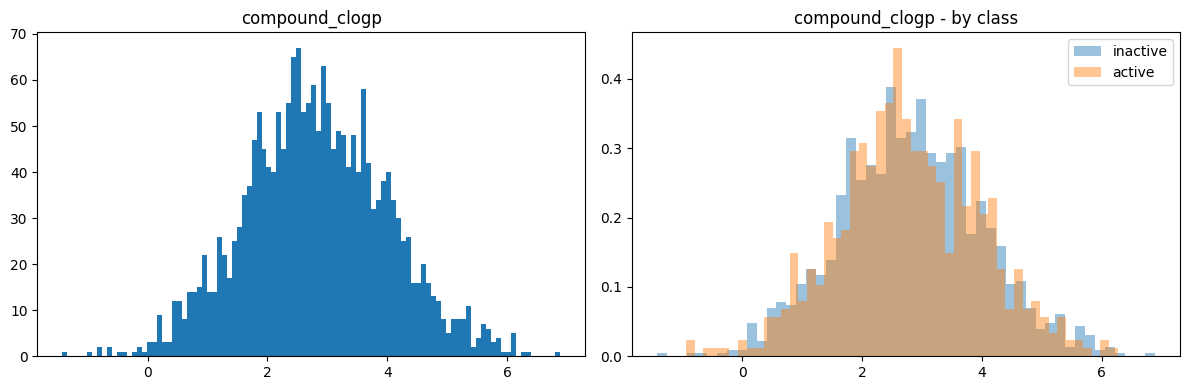

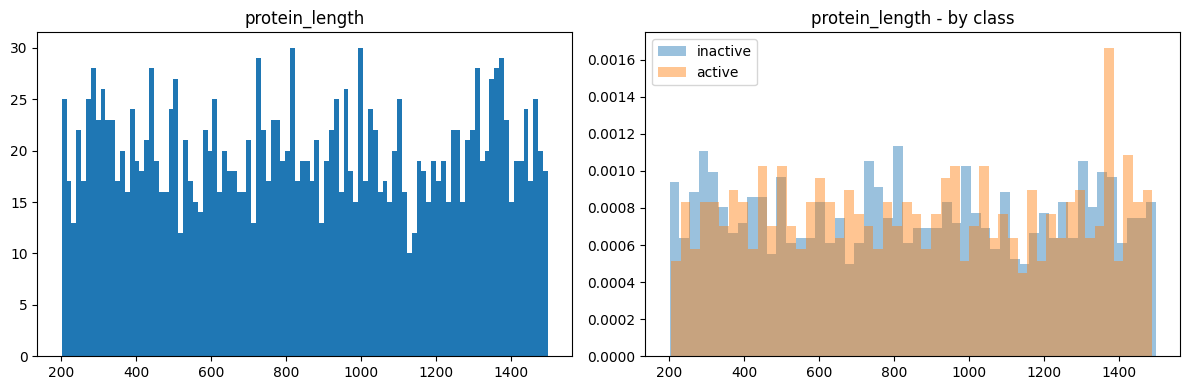

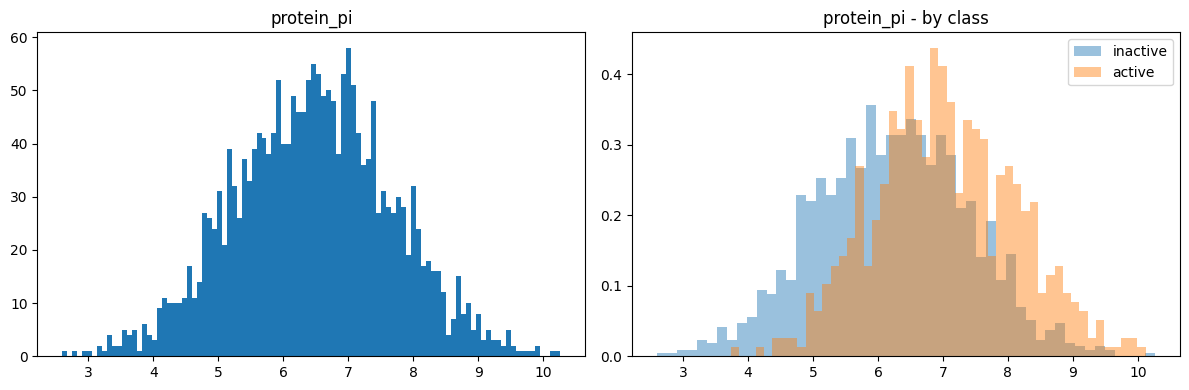

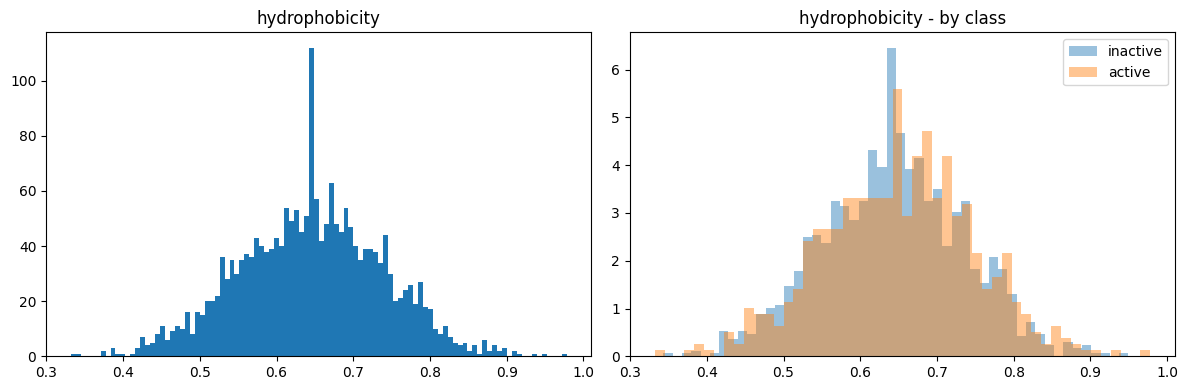

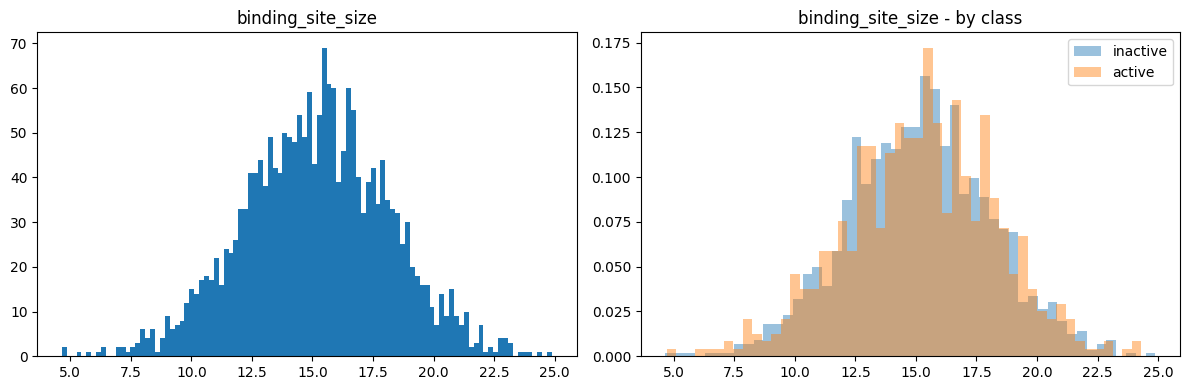

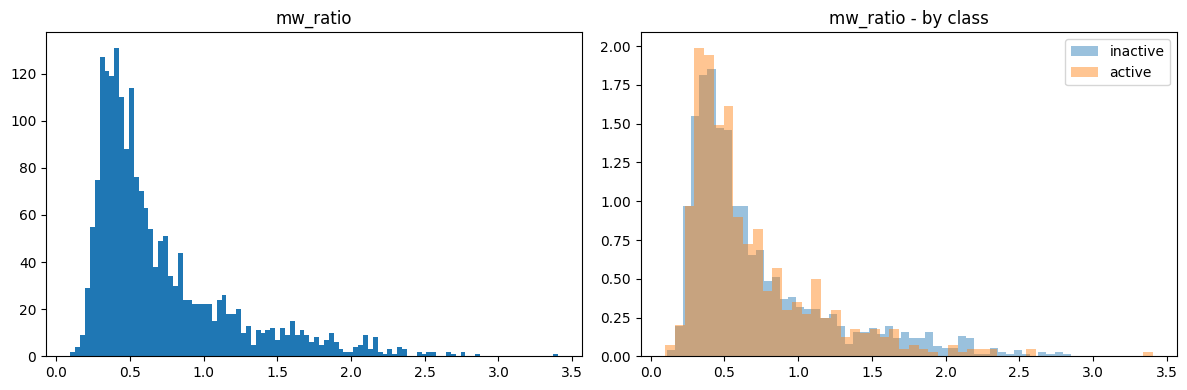

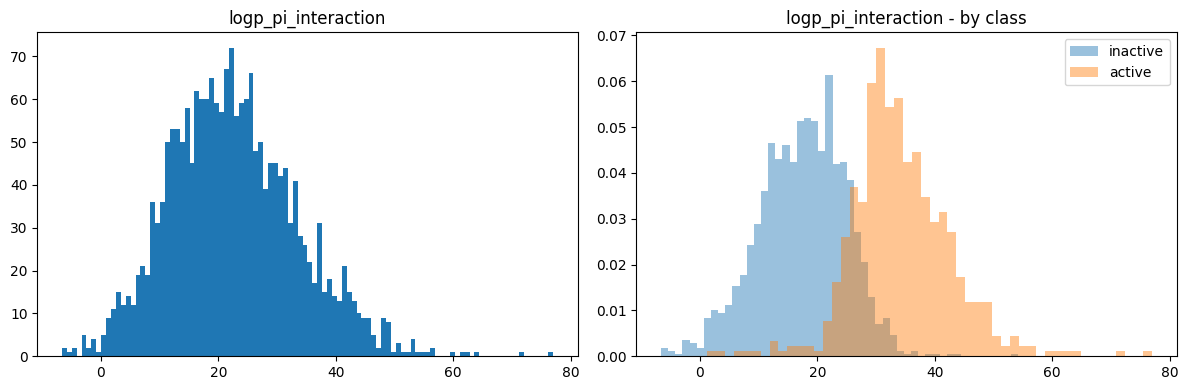

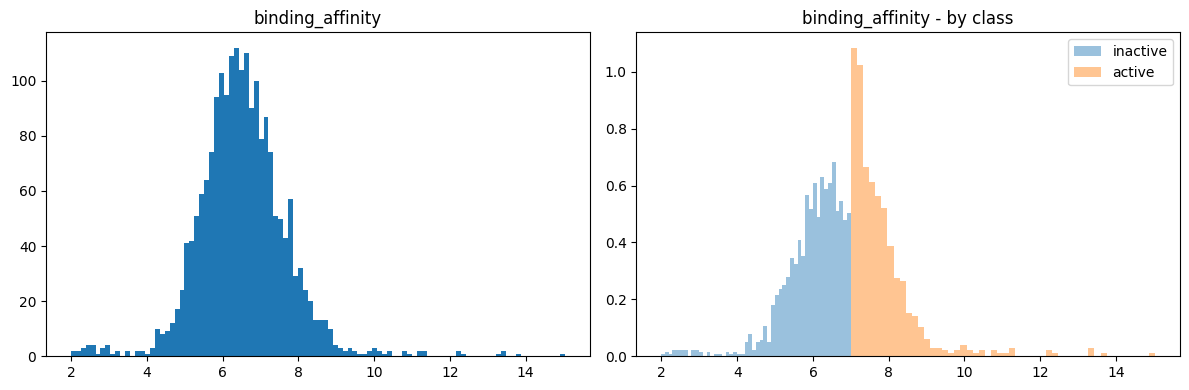

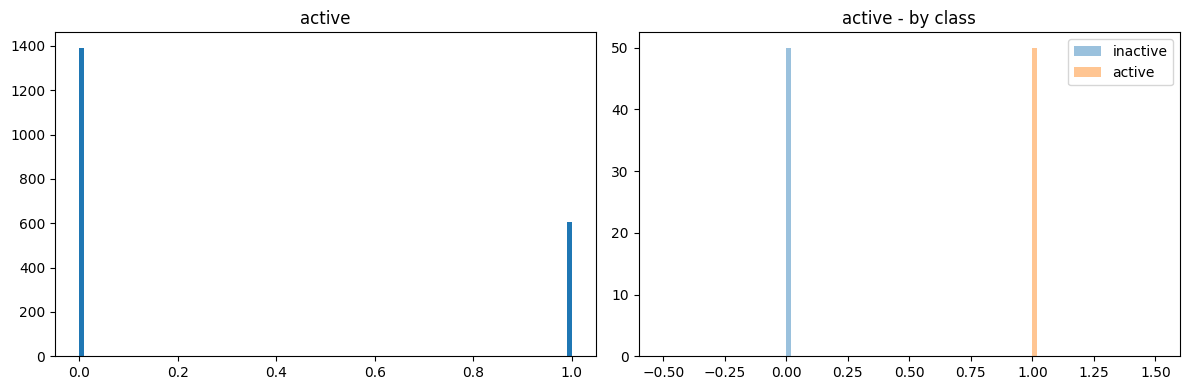

In [52]:
for col in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df[col], bins=100)
    axes[0].set_title(col)

    inactive = df[df["active"] == 0][col]
    active   = df[df["active"] == 1][col]
    axes[1].hist(inactive, bins=50, alpha=0.45, label="inactive", density=True)
    axes[1].hist(active,   bins=50, alpha=0.45, label="active",   density=True)
    axes[1].set_title(f"{col} - by class")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

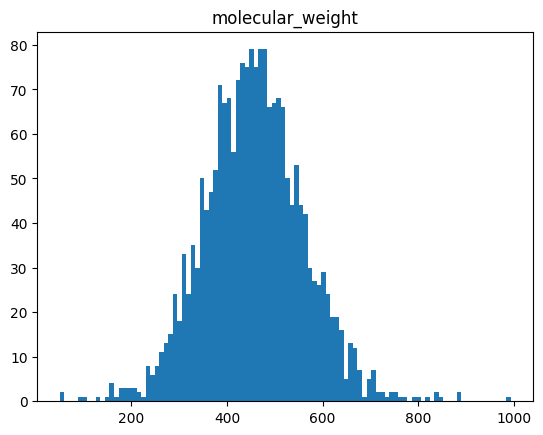

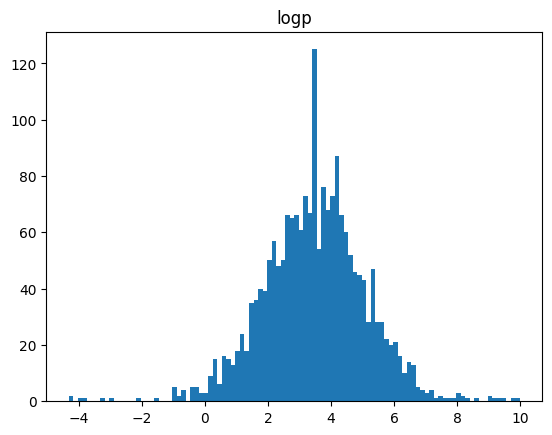

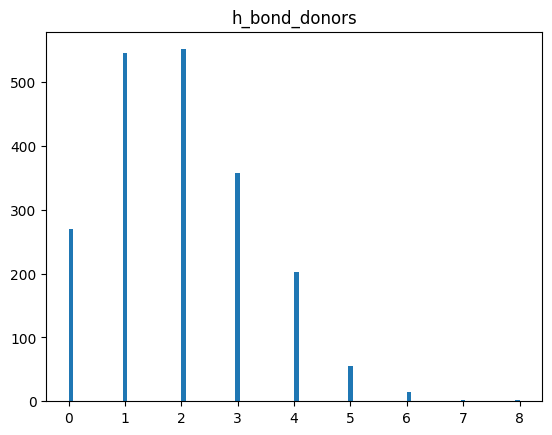

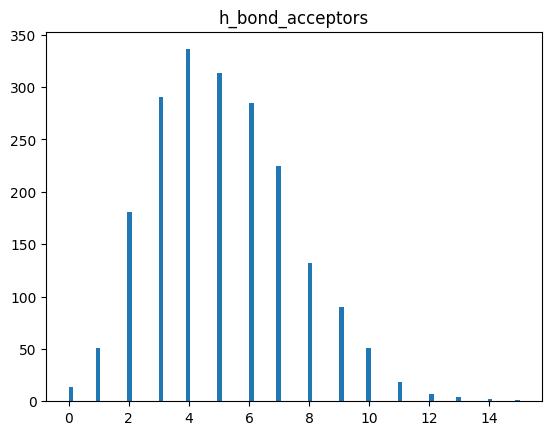

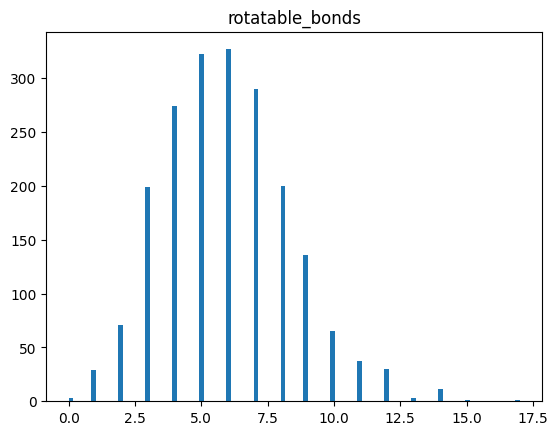

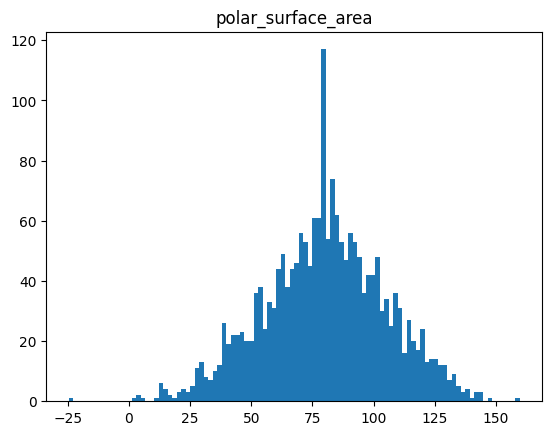

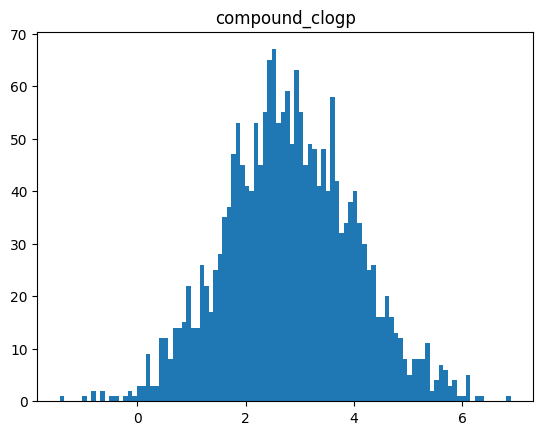

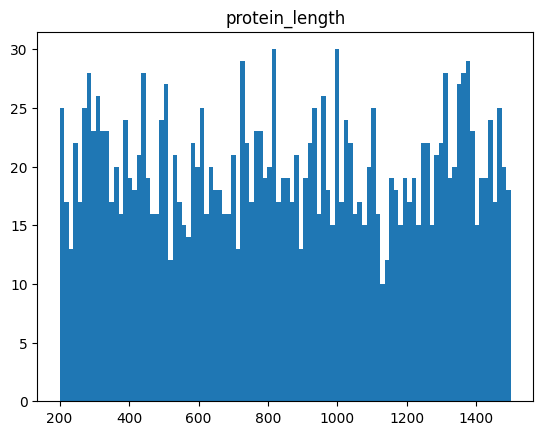

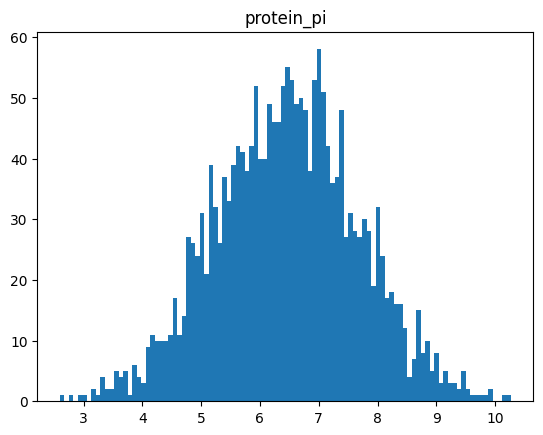

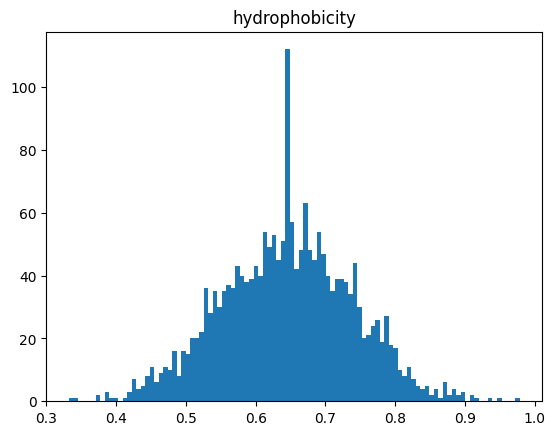

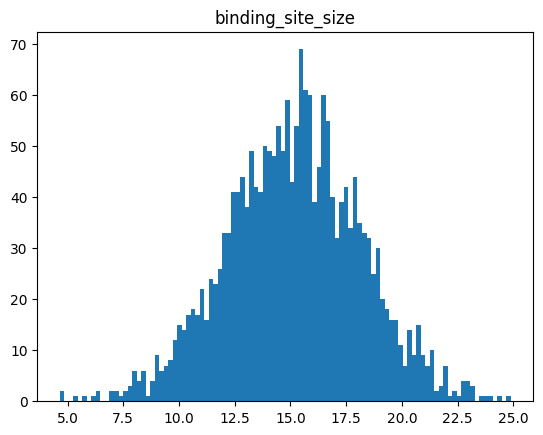

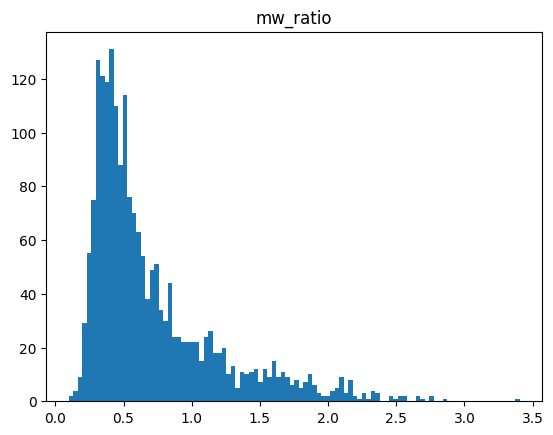

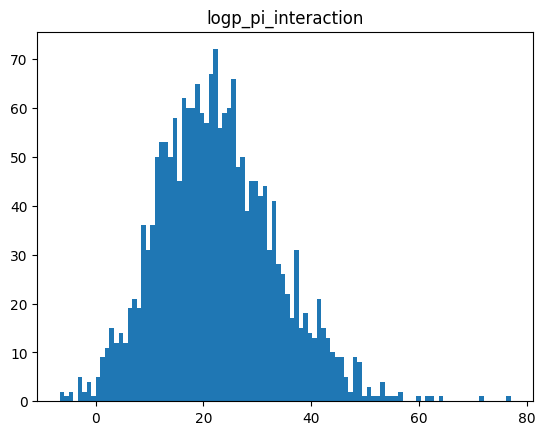

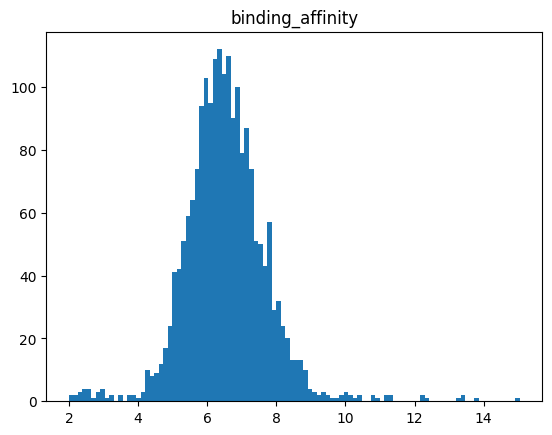

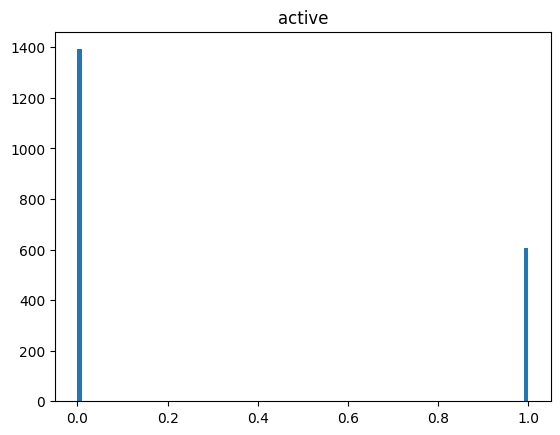

In [5]:
for col in df.columns:
    plt.hist(df[col], bins=100)
    plt.title(col)
    plt.show()